# APC MNIST Guide (Simplified)

This notebook is a compact, notebook-first APC training walkthrough for MNIST.

Design choices are intentionally fixed to keep code short:

- Binomial data distribution
- Conv-PC encoder
- NN decoder
- AdamW optimizer
- MultiStepLR scheduler (milestones at 66% and 90%)
- Training progress printed only at 10%, 20%, ..., 100%
- Inline metrics and reconstructions only (no checkpoint/JSON/image file outputs)


## Imports

We keep imports explicit so you can quickly see which pieces handle modeling, training, and visualization.

- Standard library: lightweight config and serialization helpers
- PyTorch + Lightning Fabric: tensor ops and runtime orchestration
- SPFlow APC modules: encoder/decoder/model/loss tooling
- Torchvision + plotting stack: data loading and inline analysis


In [35]:
from __future__ import annotations

# Standard-library helpers for config handling and lightweight reporting.
import json
import math
from dataclasses import asdict, dataclass
from pathlib import Path

# Core scientific stack used throughout the notebook.
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader, random_split

# APC/SPFlow model components.
from spflow.modules.leaves import Binomial, Normal
from spflow.modules.leaves.leaf import LeafModule
from spflow.zoo.apc.config import ApcConfig, ApcLossWeights
from spflow.zoo.apc.decoders import NeuralDecoder2D
from spflow.zoo.apc.encoders.convpc_joint_encoder import ConvPcJointEncoder
from spflow.zoo.apc.model import AutoencodingPC
from spflow.zoo.apc.train import evaluate_apc

# Runtime orchestration and dataset transforms/utilities.
import lightning as L
from torchvision import datasets, transforms
from torchvision.utils import make_grid


## Defaults

A single dataclass holds all fixed tutorial settings so runs stay reproducible and easy to modify.

These values prioritize a fast, stable guide run over full hyperparameter tuning.


In [36]:
@dataclass
class Config:
    """Fixed configuration for this simplified APC MNIST tutorial notebook."""

    # Reproducibility and dataset location.
    seed: int = 0
    data_dir: Path = Path("./data/mnist")
    download: bool = True

    # Input representation used in this notebook.
    dist_data: str = "binomial"
    image_size: int = 32
    n_bits: int = 8

    # Runtime execution settings.
    device: str = "auto"
    precision: str = "bf16-mixed"
    num_workers: int = 0

    # Training budget and dataset caps for notebook speed.
    iters: int = 1000
    batch_size: int = 128
    val_size: int = 10_000
    max_train_samples: int | None = 60_000
    max_val_samples: int | None = 2_000
    max_test_samples: int | None = 2_000

    # Optimizer and scheduler hyperparameters.
    lr_encoder: float = 1e-1
    lr_decoder: float = 1e-3
    weight_decay: float = 0.0
    lr_gamma: float = 0.1

    # Encoder/decoder architecture controls.
    latent_dim: int = 64
    conv_channels: int = 64
    conv_depth: int = 3
    conv_latent_depth: int = 0
    conv_use_sum_conv: bool = False
    num_repetitions: int = 1

    nn_hidden: int = 64
    nn_res_hidden: int = 16
    nn_res_layers: int = 2
    nn_scales: int = 2
    nn_bn: bool = True
    nn_out_activation: str = "identity"

    # APC objective weighting and sampling setup.
    rec_loss: str = "mse"
    sample_tau: float = 1.0
    w_rec: float = 1.0
    w_kld: float = 1.0
    w_nll: float = 1.0

    grad_clip_norm: float | None = None
    warmup_pct: float = 2.0
    num_vis: int = 8


cfg = Config()
cfg


Config(seed=0, data_dir=PosixPath('data/mnist'), download=True, dist_data='binomial', image_size=32, n_bits=8, device='auto', precision='bf16-mixed', num_workers=0, iters=1000, batch_size=128, val_size=10000, max_train_samples=60000, max_val_samples=2000, max_test_samples=2000, lr_encoder=0.1, lr_decoder=0.001, weight_decay=0.0, lr_gamma=0.1, latent_dim=64, conv_channels=64, conv_depth=3, conv_latent_depth=0, conv_use_sum_conv=False, num_repetitions=1, nn_hidden=64, nn_res_hidden=16, nn_res_layers=2, nn_scales=2, nn_bn=True, nn_out_activation='identity', rec_loss='mse', sample_tau=1.0, w_rec=1.0, w_kld=1.0, w_nll=1.0, grad_clip_norm=None, warmup_pct=2.0, num_vis=8)

### Configuration Notes

When you start experimenting, change one group of settings at a time:

- `iters` / `batch_size`: runtime and optimization smoothness
- `latent_dim` + conv settings: encoder capacity
- `w_rec`, `w_kld`, `w_nll`: reconstruction vs regularization trade-off

Small, isolated changes make the loss table and reconstructions easier to interpret.


## Minimal Helpers (Data, Model, Train)

This helper block keeps the rest of the notebook compact by grouping the end-to-end APC workflow:

1. Build deterministic dataset splits and loaders
2. Construct the Conv-PC encoder + neural decoder APC model
3. Configure optimizer and learning-rate schedule
4. Train for a fixed iteration budget with periodic validation
5. Build a reconstruction grid for qualitative inspection


In [37]:
def seed_everything(seed: int) -> None:
    """Seed torch RNGs for reproducible notebook runs."""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(name: str) -> torch.device:
    """Resolve the runtime device from `auto`, `cpu`, or `cuda`."""
    if name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(name)


def build_fabric(*, device: torch.device, precision: str) -> L.Fabric:
    """Create a single-device Lightning Fabric runtime."""
    accelerator = "cuda" if device.type == "cuda" else "cpu"
    return L.Fabric(accelerator=accelerator, devices=1, precision=precision)


class QuantizeToNBits:
    """Torchvision transform: map pixels to integer counts in [0, 2^n_bits-1]."""

    def __init__(self, n_bits: int) -> None:
        self.n_bits = int(n_bits)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        max_value = float(2**self.n_bits - 1)
        return torch.floor(x * max_value)


def _cap_subset(subset: torch.utils.data.Subset, max_samples: int | None) -> torch.utils.data.Subset:
    """Optionally cap a subset length for quick notebook iterations."""
    if max_samples is None or max_samples >= len(subset):
        return subset
    return torch.utils.data.Subset(subset.dataset, subset.indices[:max_samples])


def build_loaders(cfg: Config) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Build train/val/test dataloaders for MNIST with fixed binomial preprocessing."""
    # Keep preprocessing fixed so architecture/loss changes are easier to compare.
    if cfg.dist_data != "binomial":
        raise ValueError(f"This notebook only supports dist_data='binomial', got {cfg.dist_data!r}")

    tfm = transforms.Compose(
        [
            transforms.Resize((cfg.image_size, cfg.image_size)),
            transforms.ToTensor(),
            QuantizeToNBits(cfg.n_bits),
        ]
    )

    train_full = datasets.MNIST(root=str(cfg.data_dir), train=True, transform=tfm, download=cfg.download)
    test_full = datasets.MNIST(root=str(cfg.data_dir), train=False, transform=tfm, download=cfg.download)

    if cfg.val_size <= 0 or cfg.val_size >= len(train_full):
        raise ValueError(f"val_size must be in [1, {len(train_full)-1}], got {cfg.val_size}")

    # Use a seeded generator so train/validation split is deterministic.
    gen = torch.Generator().manual_seed(cfg.seed)
    train_subset, val_subset = random_split(
        train_full, [len(train_full) - cfg.val_size, cfg.val_size], generator=gen
    )

    train_subset = _cap_subset(train_subset, cfg.max_train_samples)
    val_subset = _cap_subset(val_subset, cfg.max_val_samples)
    test_subset = _cap_subset(torch.utils.data.Subset(test_full, list(range(len(test_full)))), cfg.max_test_samples)

    # Pin memory only when CUDA is used to speed up host-to-device copies.
    pin = torch.cuda.is_available() and resolve_device(cfg.device).type == "cuda"
    train_loader = DataLoader(train_subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=pin)
    val_loader = DataLoader(val_subset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
    test_loader = DataLoader(test_subset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
    return train_loader, val_loader, test_loader


def make_x_leaf_factory(n_bits: int):
    """Create the observed-data leaf factory (Binomial)."""
    total_count_tensor = torch.tensor(float(2**n_bits - 1))

    def _factory(scope_indices: list[int], out_channels: int, num_repetitions: int) -> LeafModule:
        shape = (len(scope_indices), out_channels, num_repetitions)
        probs = 0.5 + (torch.rand(shape) - 0.5) * 0.2
        return Binomial(
            scope=scope_indices,
            out_channels=out_channels,
            num_repetitions=num_repetitions,
            total_count=total_count_tensor,
            probs=probs,
        )

    return _factory


def make_z_leaf_factory():
    """Create the latent leaf factory (Normal)."""

    def _factory(scope_indices: list[int], out_channels: int, num_repetitions: int) -> LeafModule:
        shape = (len(scope_indices), out_channels, num_repetitions)
        loc = torch.randn(shape)
        logvar = torch.randn(shape)
        scale = torch.exp(0.5 * logvar)
        return Normal(
            scope=scope_indices,
            out_channels=out_channels,
            num_repetitions=num_repetitions,
            loc=loc,
            scale=scale,
        )

    return _factory


def build_model(cfg: Config) -> AutoencodingPC:
    """Build a fixed Conv-PC encoder with an NN decoder."""
    encoder = ConvPcJointEncoder(
        input_height=cfg.image_size,
        input_width=cfg.image_size,
        input_channels=1,
        latent_dim=cfg.latent_dim,
        channels=cfg.conv_channels,
        depth=cfg.conv_depth,
        kernel_size=2,
        num_repetitions=cfg.num_repetitions,
        use_sum_conv=cfg.conv_use_sum_conv,
        latent_depth=cfg.conv_latent_depth,
        architecture="reference",
        perm_latents=False,
        x_leaf_factory=make_x_leaf_factory(cfg.n_bits),
        z_leaf_factory=make_z_leaf_factory(),
    )

    decoder = NeuralDecoder2D(
        latent_dim=cfg.latent_dim,
        output_shape=(1, cfg.image_size, cfg.image_size),
        num_hidden=cfg.nn_hidden,
        num_res_hidden=cfg.nn_res_hidden,
        num_res_layers=cfg.nn_res_layers,
        num_scales=cfg.nn_scales,
        bn=cfg.nn_bn,
        out_activation=cfg.nn_out_activation,
    )

    apc_config = ApcConfig(
        latent_dim=cfg.latent_dim,
        rec_loss=cfg.rec_loss,
        sample_tau=cfg.sample_tau,
        loss_weights=ApcLossWeights(rec=cfg.w_rec, kld=cfg.w_kld, nll=cfg.w_nll),
    )
    return AutoencodingPC(encoder=encoder, decoder=decoder, config=apc_config)


def build_optimizer(cfg: Config, model: AutoencodingPC) -> Optimizer:
    """Build AdamW with separate encoder/decoder learning rates."""
    return AdamW(
        [
            {"params": model.encoder.parameters(), "lr": cfg.lr_encoder},
            {"params": model.decoder.parameters(), "lr": cfg.lr_decoder},
        ],
        weight_decay=cfg.weight_decay,
    )


def build_scheduler(cfg: Config, optimizer: Optimizer) -> MultiStepLR:
    """Build fixed MultiStepLR with milestones at 66% and 90% of training."""
    milestones = sorted({max(1, int(0.66 * cfg.iters)), max(1, int(0.9 * cfg.iters))})
    return MultiStepLR(optimizer, milestones=milestones, gamma=cfg.lr_gamma)


def _extract_x(batch: torch.Tensor | tuple | list) -> torch.Tensor:
    """Extract the image tensor from `(x, y)` dataset batches."""
    if isinstance(batch, torch.Tensor):
        return batch
    if isinstance(batch, (tuple, list)) and len(batch) > 0 and isinstance(batch[0], torch.Tensor):
        return batch[0]
    raise TypeError(f"Unsupported batch type: {type(batch)}")


def collect_vis_batch(loader: DataLoader, device: torch.device, num_vis: int) -> torch.Tensor:
    """Collect a small fixed test batch used for reconstruction visualization."""
    chunks: list[torch.Tensor] = []
    n = 0
    for batch in loader:
        x = _extract_x(batch).to(device)
        take = min(num_vis - n, x.shape[0])
        chunks.append(x[:take])
        n += take
        if n >= num_vis:
            break
    if not chunks:
        raise RuntimeError("Could not collect visualization samples")
    return torch.cat(chunks, dim=0)


def _to_image_batch(x: torch.Tensor, image_size: int) -> torch.Tensor:
    """Ensure tensors are in image shape `(B, 1, H, W)`."""
    if x.dim() == 4 and x.shape[1:] == (1, image_size, image_size):
        return x
    if x.dim() == 2 and x.shape[1] == image_size * image_size:
        return x.view(-1, 1, image_size, image_size)
    raise ValueError(f"Unexpected shape {tuple(x.shape)}")


def build_recon_grid(model: AutoencodingPC, x_batch: torch.Tensor, cfg: Config) -> torch.Tensor:
    """Return an inline visualization grid (top row data, bottom row reconstruction)."""
    model.eval()
    with torch.no_grad():
        x_rec = model.reconstruct(x_batch)

    denom = float(2**cfg.n_bits - 1)
    x_img = _to_image_batch(x_batch.detach().cpu(), cfg.image_size).float().div(denom).clamp(0.0, 1.0)
    x_rec_img = _to_image_batch(x_rec.detach().cpu(), cfg.image_size).float().div(denom).clamp(0.0, 1.0)
    return make_grid(torch.cat([x_img, x_rec_img], dim=0), nrow=x_img.shape[0], padding=1, pad_value=1.0)


def _progress_map(iters: int) -> dict[int, int]:
    """Map training steps to progress percentages: 10, 20, ..., 100."""
    marks: dict[int, int] = {}
    for p in range(1, 11):
        step = max(1, int(round(iters * p / 10)))
        marks[step] = p * 10
    return marks


def train_apc_iters(
    *,
    fabric: L.Fabric,
    model: AutoencodingPC,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: Optimizer,
    scheduler: MultiStepLR,
    cfg: Config,
) -> list[dict[str, float]]:
    """Train for a fixed iteration budget and log exactly 10 progress lines."""
    history: list[dict[str, float]] = []
    train_iter = iter(train_loader)

    base_lrs = [float(group["lr"]) for group in optimizer.param_groups]
    # Warmup duration is expressed as a fraction of total iterations.
    warmup_steps = int(cfg.iters * cfg.warmup_pct / 100.0)
    progress_marks = _progress_map(cfg.iters)

    # Track running means between progress checkpoints.
    window_totals = {"rec": 0.0, "kld": 0.0, "nll": 0.0, "total": 0.0}
    window_steps = 0

    for step in range(1, cfg.iters + 1):
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)

        x = _extract_x(batch).to(fabric.device)

        model.train()
        optimizer.zero_grad(set_to_none=True)
        losses = model.loss_components(x)
        fabric.backward(losses["total"])

        if cfg.grad_clip_norm is not None:
            fabric.clip_gradients(model, optimizer, max_norm=cfg.grad_clip_norm)

        optimizer.step()
        scheduler.step()

        # Keep the script-style warmup behavior in compact form.
        if warmup_steps > 0 and step <= warmup_steps:
            factor = math.exp(-5.0 * (1.0 - (step / warmup_steps)) ** 2)
            for group, base_lr in zip(optimizer.param_groups, base_lrs):
                group["lr"] = base_lr * factor

        for k in window_totals:
            window_totals[k] += float(losses[k].item())
        window_steps += 1

        if step not in progress_marks:
            continue

        # Run validation only at progress checkpoints to keep notebook runtime low.
        val = evaluate_apc(model, val_loader, batch_size=cfg.batch_size)
        row = {
            "iter": float(step),
            "progress_pct": float(progress_marks[step]),
            "train_total": window_totals["total"] / window_steps,
            "train_rec": window_totals["rec"] / window_steps,
            "train_kld": window_totals["kld"] / window_steps,
            "train_nll": window_totals["nll"] / window_steps,
            "val_total": float(val["total"]),
            "val_rec": float(val["rec"]),
            "val_kld": float(val["kld"]),
            "val_nll": float(val["nll"]),
        }
        history.append(row)

        print(
            f"[APC] {int(row['progress_pct']):3d}% ({step}/{cfg.iters}) "
            f"train_total={row['train_total']:.4f} val_total={row['val_total']:.4f}"
        )

        window_totals = {"rec": 0.0, "kld": 0.0, "nll": 0.0, "total": 0.0}
        window_steps = 0

    return history


### Before Running Training

The run cell follows this order:

1. Set seed/device/Fabric
2. Build loaders, model, optimizer, scheduler
3. Move components into Fabric-managed runtime
4. Train, evaluate on test set, and prepare plotting payloads


## Training

The following wires all helper functions into one runnable pipeline and prints compact progress logs at 10% checkpoints.


In [38]:
# Seed first so data splits and initial parameters remain reproducible.
seed_everything(cfg.seed)

# Resolve backend and initialize a single-device Fabric runtime.
device = resolve_device(cfg.device)
fabric = build_fabric(device=device, precision=cfg.precision)

# Build data pipeline and APC model from the fixed config.
train_loader, val_loader, test_loader = build_loaders(cfg)
model = build_model(cfg)
optimizer = build_optimizer(cfg, model)
scheduler = build_scheduler(cfg, optimizer)

# Let Fabric place loaders/model/optimizer on the selected runtime device.
train_loader, val_loader, test_loader = fabric.setup_dataloaders(train_loader, val_loader, test_loader)
# Keep a fixed mini-batch for consistent reconstruction snapshots.
vis_batch = collect_vis_batch(test_loader, device=device, num_vis=cfg.num_vis)
model, optimizer = fabric.setup(model, optimizer)

print(f"[APC] Device: {device}")
print(
    f"[APC] Dataset sizes: train={len(train_loader.dataset)}, val={len(val_loader.dataset)}, test={len(test_loader.dataset)}"
)
print(
    f"[APC] Fixed setup: Conv-PC + NN decoder, AdamW, MultiStepLR(66/90), "
    f"batch_size={cfg.batch_size}, iters={cfg.iters}"
)

# Run the fixed-iteration training loop.
history = train_apc_iters(
    fabric=fabric,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    cfg=cfg,
)

# Evaluate on held-out data and unwrap model if Fabric wrapped it.
test_metrics = evaluate_apc(model, test_loader, batch_size=cfg.batch_size)
model_unwrapped = model.module if hasattr(model, "module") else model

history_df = pd.DataFrame(history)
recon_grid = build_recon_grid(model_unwrapped, vis_batch, cfg)

inline_payload = {
    "config": {k: (str(v) if isinstance(v, Path) else v) for k, v in asdict(cfg).items()},
    "apc_config": asdict(model_unwrapped.config),
    "test_metrics": test_metrics,
}

print("[APC] Test metrics:", test_metrics)

Using bfloat16 Automatic Mixed Precision (AMP)


[APC] Device: cpu
[APC] Dataset sizes: train=50000, val=2000, test=2000
[APC] Fixed setup: Conv-PC + NN decoder, AdamW, MultiStepLR(66/90), batch_size=128, iters=1000
[APC]  10% (100/1000) train_total=4504533.5300 val_total=2967835.8420
[APC]  20% (200/1000) train_total=2212066.5950 val_total=1748269.8230
[APC]  30% (300/1000) train_total=1558427.6600 val_total=1445993.7350
[APC]  40% (400/1000) train_total=1366740.8050 val_total=1326261.4410
[APC]  50% (500/1000) train_total=1273774.9087 val_total=1247038.0190
[APC]  60% (600/1000) train_total=1229806.9688 val_total=1215286.8020
[APC]  70% (700/1000) train_total=1168145.4112 val_total=1143536.5570
[APC]  80% (800/1000) train_total=1128152.8813 val_total=1124754.1210
[APC]  90% (900/1000) train_total=1105665.3219 val_total=1105524.4530
[APC] 100% (1000/1000) train_total=1098820.8000 val_total=1104452.4800
[APC] Test metrics: {'rec': 1058982.502, 'kld': 904.2743515625, 'nll': 20949.222015625, 'total': 1080835.999}

[APC] Inline payload 

## Results

,iter,progress_pct,train_total,train_rec,train_kld,train_nll,val_total,val_rec,val_kld,val_nll
0,100.0,10.0,4.504534e+06,4.446900e+06,186.001488,57447.176172,2967835.842,2.939025e+06,349.067951,28461.813141
1,200.0,20.0,2.212067e+06,2.185646e+06,513.629837,25907.362402,1748269.823,1.723398e+06,635.257547,24236.865609
2,300.0,30.0,1.558428e+06,1.534141e+06,695.762187,23591.010215,1445993.735,1.422170e+06,747.875771,23076.016375
3,400.0,40.0,1.366741e+06,1.343259e+06,773.251157,22708.204551,1326261.441,1.303142e+06,799.736663,22320.137344
4,500.0,50.0,1.273775e+06,1.250953e+06,835.988552,21985.431719,1247038.019,1.224443e+06,862.661738,21732.708234
5,600.0,60.0,1.229807e+06,1.207507e+06,887.402727,21412.433613,1215286.802,1.192928e+06,896.726700,21462.263781
6,700.0,70.0,1.168145e+06,1.145592e+06,911.301548,21642.418105,1143536.557,1.120679e+06,912.463941,21945.340609
7,800.0,80.0,1.128153e+06,1.105444e+06,921.173979,21787.575938,1124754.121,1.102065e+06,914.862308,21774.091844
8,900.0,90.0,1.105665e+06,1.083133e+06,917.388387,21614.657539,1105524.453,1.083016e+06,915.413808,21593.535422
9,1000.0,100.0,1.098821e+06,1.076440e+06,919.010759,21461.837246,1104452.480,1.081957e+06,917.645335,21577.747719


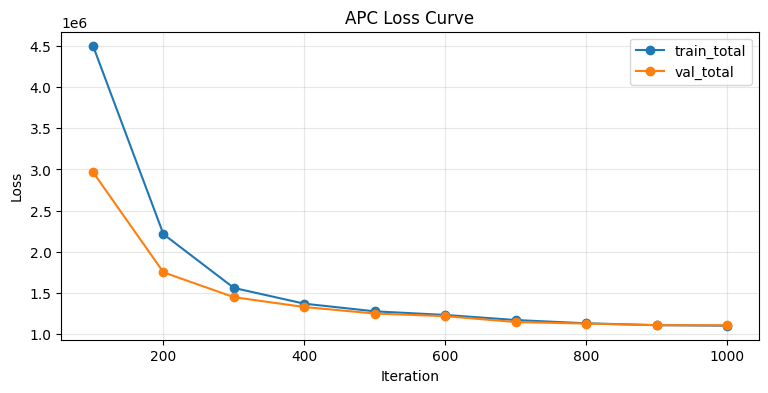

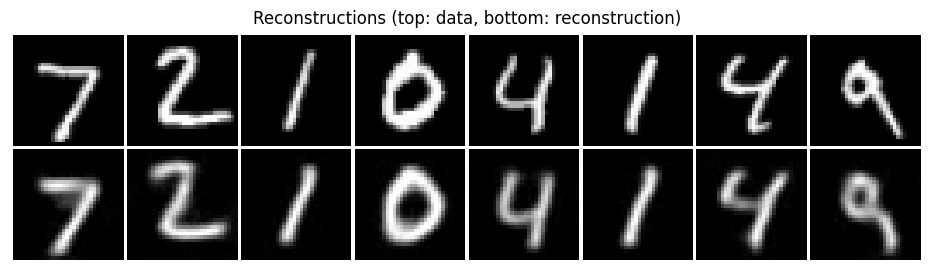

In [39]:
# Show the checkpoint-level training history table.
display(history_df)
# Plot train/validation total loss across 10% progress checkpoints.
plt.figure(figsize=(9, 4))
plt.plot(history_df["iter"], history_df["train_total"], marker="o", label="train_total")
plt.plot(history_df["iter"], history_df["val_total"], marker="o", label="val_total")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("APC Loss Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Display originals (top row) against reconstructions (bottom row).
img = recon_grid.detach().cpu()
plt.figure(figsize=(12, 3))
if img.shape[0] == 1:
    plt.imshow(img.squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
else:
    plt.imshow(img.permute(1, 2, 0).clamp(0.0, 1.0))
plt.axis("off")
plt.title("Reconstructions (top: data, bottom: reconstruction)")
plt.show()
